# Extract Gene Embeddings with Geneformer

Extract gene embeddings from `Immune_ALL_human.h5ad` using the pretrained
Geneformer model and visualize with UMAP.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import scanpy as sc
import torch
from geneformer import ENSEMBL_DICTIONARY_FILE, EmbExtractor, TranscriptomeTokenizer

DATA_DIR = Path("../data")
TOKENIZED_DIR = DATA_DIR / "geneformer_tokenized"
OUTPUT_DIR = DATA_DIR / "geneformer_output"
MODEL_NAME = "ctheodoris/Geneformer"

TOKENIZED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"CUDA available: {torch.cuda.is_available()}")

/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True


## Load and inspect data

In [2]:
adata = sc.read(DATA_DIR / "Immune_ALL_human.h5ad")
print(f"Dataset: {adata.shape[0]} cells, {adata.shape[1]} genes")
print(f"var columns: {list(adata.var.columns)}")
print(f"obs columns: {list(adata.obs.columns)}")
print(f"First 5 var_names: {list(adata.var_names[:5])}")

## TODO: Stratify data to cel types, get embeddings from a single cell type at a time
## Does this impact ranking?

Dataset: 33506 cells, 12303 genes
var columns: []
obs columns: ['batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue']
First 5 var_names: ['LINC00115', 'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17']


## Map gene names to Ensembl IDs

Geneformer requires `ensembl_id` in `adata.var` and `n_counts` in `adata.obs`.
We use geneformer's bundled gene name → Ensembl ID dictionary for mapping.

In [3]:
# Load geneformer's gene name → Ensembl ID dictionary
with open(ENSEMBL_DICTIONARY_FILE, "rb") as f:
    gene_name_to_ensembl = pickle.load(f)

print(f"Genes in mapping dict: {len(gene_name_to_ensembl)}")

# Map var_names to Ensembl IDs
ensembl_ids = [gene_name_to_ensembl.get(gene, "unknown") for gene in adata.var_names]
adata.var["ensembl_id"] = ensembl_ids

mapped = sum(1 for eid in ensembl_ids if eid != "unknown")
print(f"Mapped {mapped}/{len(ensembl_ids)} genes to Ensembl IDs")

# Ensure n_counts exists
if "n_counts" not in adata.obs.columns:
    adata.obs["n_counts"] = np.array(adata.X.sum(axis=1)).flatten()
    print("Computed n_counts from raw counts")
else:
    print("n_counts already present")

## TODO: specify cells to extract embeddings from

# Identify highly variable genes (matching scGPT's N_HVG=1200)
# adata_hvg = adata.copy()
# sc.pp.normalize_total(adata_hvg)
# sc.pp.log1p(adata_hvg)
# sc.pp.highly_variable_genes(adata_hvg, n_top_genes=1200)
# hvg_names = set(adata_hvg.var_names[adata_hvg.var.highly_variable])
# hvg_ensembl = {gene_name_to_ensembl[g] for g in hvg_names if g in gene_name_to_ensembl}
# print(f"HVGs selected: {len(hvg_names)}, mapped to Ensembl: {len(hvg_ensembl)}")
# del adata_hvg

# Save prepared h5ad for tokenization (tokenizer reads from a directory)
PREP_DIR = DATA_DIR / "geneformer_prep"
PREP_DIR.mkdir(exist_ok=True)
prep_path = PREP_DIR / "Immune_ALL_human.h5ad"
adata.write(prep_path)
print(f"Saved prepared h5ad to {prep_path}")

Genes in mapping dict: 63675
Mapped 12014/12303 genes to Ensembl IDs
n_counts already present
Saved prepared h5ad to ../data/geneformer_prep/Immune_ALL_human.h5ad


## Tokenize with TranscriptomeTokenizer

In [4]:
tk = TranscriptomeTokenizer(
    custom_attr_name_dict={"final_annotation": "cell_type"},
    nproc=4,
)
tk.tokenize_data(
    data_directory=PREP_DIR,
    output_directory=TOKENIZED_DIR,
    output_prefix="immune_human",
    file_format="h5ad",
)
print(f"Tokenized dataset saved to {TOKENIZED_DIR / 'immune_human.dataset'}")

Tokenizing ../data/geneformer_prep/Immune_ALL_human.h5ad


/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


../data/geneformer_prep/Immune_ALL_human.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Tokenized dataset saved to ../data/geneformer_tokenized/immune_human.dataset


## Extract gene embeddings

In [6]:
from datasets import load_from_disk
import math, shutil, tempfile, functools

CELL_TYPE = "CD20+ B cells"
CHUNK_SIZE = 50

# Load tokenized data and filter to target cell type
tokenized_data = load_from_disk(str(TOKENIZED_DIR / 'immune_human.dataset'))
cd4_data = tokenized_data.filter(lambda x: x["cell_type"] == CELL_TYPE, num_proc=4)
cd4_data = cd4_data.sort("length", reverse=True)
n_cells = len(cd4_data)
n_chunks = math.ceil(n_cells / CHUNK_SIZE)
print(f"{CELL_TYPE}: {n_cells} cells, {n_chunks} chunks of {CHUNK_SIZE}")

# # Process each chunk
# chunk_embs = []
# chunk_sizes = []
# for i in range(n_chunks):
#     start = i * CHUNK_SIZE
#     end = min(start + CHUNK_SIZE, n_cells)
#     chunk = cd4_data.select(range(start, end))
#     chunk_size = end - start

#     # Save chunk as temporary dataset
#     tmp_dir = Path(tempfile.mkdtemp())
#     chunk_path = tmp_dir / "chunk.dataset"
#     chunk.save_to_disk(str(chunk_path))

#     embex = EmbExtractor(
#         model_type="Pretrained",
#         emb_mode="gene",
#         max_ncells=None,
#         emb_layer=-1,
#         forward_batch_size=2,
#         summary_stat="mean",
#     )
#     embs_df = embex.extract_embs(
#         model_directory=MODEL_NAME,
#         input_data_file=chunk_path,
#         output_directory=OUTPUT_DIR,
#         output_prefix=f"gene_embs_cd4_chunk_{i}",
#     )
#     chunk_embs.append(embs_df)
#     chunk_sizes.append(chunk_size)
#     shutil.rmtree(tmp_dir)
#     print(f"  Chunk {i+1}/{n_chunks}: {chunk_size} cells, {embs_df.shape[0]} genes")

# # Weighted average across chunks using union of all genes.
# # Genes absent from a chunk are filled with 0 (not expressed in those cells).
# weights = np.array(chunk_sizes) / sum(chunk_sizes)
# all_genes = sorted(functools.reduce(lambda a, b: a.union(b),
#                                     [set(df.index) for df in chunk_embs]))
# emb_cols = chunk_embs[0].columns
# embs_df = sum(
#     w * df.reindex(all_genes, fill_value=0.0)
#     for w, df in zip(weights, chunk_embs)
# )
# print(f"Final gene embeddings: {embs_df.shape}")
# embs_df.to_csv(OUTPUT_DIR / "gene_embs_cd20.csv")

CD20+ B cells: 2873 cells, 58 chunks of 50


In [7]:
import glob
import pandas as pd

# Load pre-computed chunk CSVs and combine with union weighted average.
# Chunk sizes: all chunks have CHUNK_SIZE cells except the last.
chunk_paths = sorted(
    glob.glob(str(OUTPUT_DIR / "gene_embs_cd4_chunk_*.csv")),
    key=lambda p: int(Path(p).stem.split("_")[-1]),
)
print(f"Found {len(chunk_paths)} chunk files")

chunk_embs = [pd.read_csv(p, index_col=0) for p in chunk_paths]

n_chunks = len(chunk_embs)
last_chunk_size = n_cells % CHUNK_SIZE or CHUNK_SIZE
chunk_sizes = [CHUNK_SIZE] * (n_chunks - 1) + [last_chunk_size]
weights = np.array(chunk_sizes) / sum(chunk_sizes)

all_genes = sorted(functools.reduce(lambda a, b: a.union(b),
                                    [set(df.index) for df in chunk_embs]))
embs_df = sum(
    w * df.reindex(all_genes, fill_value=0.0)
    for w, df in zip(weights, chunk_embs)
)
print(f"Final gene embeddings: {embs_df.shape}")
embs_df.to_csv(OUTPUT_DIR / "gene_embs_cd20.csv")

Found 58 chunk files
Final gene embeddings: (11541, 1152)


## Label genes with gene symbols

Map Ensembl IDs back to human-readable gene symbols.

In [8]:
# Build reverse mapping: Ensembl ID → gene name
ensembl_to_gene_name = {v: k for k, v in gene_name_to_ensembl.items()}

# Label each gene embedding with its symbol
gene_symbols = [ensembl_to_gene_name.get(eid, eid) for eid in embs_df.index]
embs_df.insert(0, "gene_symbol", gene_symbols)

print(f"Labeled {sum(s != e for s, e in zip(gene_symbols, embs_df.index))}/{len(gene_symbols)} genes with symbols")
embs_df[["gene_symbol"]].head(10)

Labeled 11539/11541 genes with symbols


,gene_symbol
<cls>,<cls>
<eos>,<eos>
ENSG00000000419,DPM1
ENSG00000000457,SCYL3
ENSG00000000938,FGR
ENSG00000000971,CFH
ENSG00000001036,FUCA2
ENSG00000001084,GCLC
ENSG00000001167,NFYA
ENSG00000001461,NIPAL3


## UMAP of gene embeddings

In [ ]:
# Build AnnData from gene embeddings for scanpy UMAP
emb_cols = [c for c in embs_df.columns if c != "gene_symbol"]
gene_adata = sc.AnnData(
    X=embs_df[emb_cols].values.astype(np.float32),
    obs={"gene_symbol": embs_df["gene_symbol"].values},
)
gene_adata.obs_names = embs_df.index  # Ensembl IDs

sc.pp.neighbors(gene_adata, use_rep="X")
sc.tl.umap(gene_adata)
sc.pl.umap(gene_adata, title="Geneformer Gene Embeddings")

## Train Binary TRRUST Classifier

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, TensorDataset

from scfm_utils.trrust import (
    BINARY_LABEL_NAMES,
    BINARY_LABELS,
    TRRClassifierModel,
    load_binary_trrust_data,
)

TRRUST_PATH = Path("../data/trrust_rawdata.human.tsv")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64


# Load geneformer embeddings from CSV (CD20+ B cells)
emb_df = pd.read_csv(OUTPUT_DIR / "gene_embs_cd20.csv", index_col=0)
emb_df = emb_df[~emb_df.index.isin(["<cls>", "<eos>"])]

# Map Ensembl IDs to gene symbols
ensembl_to_gene_name = {v: k for k, v in gene_name_to_ensembl.items()}
gene_embeddings = {}
for ensembl_id, row in emb_df.iterrows():
    symbol = ensembl_to_gene_name.get(ensembl_id)
    if symbol is not None:
        gene_embeddings[symbol] = row.values.astype(np.float32)

embsize = emb_df.shape[1]
print(f"Gene embeddings: {len(gene_embeddings)} genes, {embsize}d")
print(f"Device: {DEVICE}")

# Restrict to scGPT binary gene list for cross-model comparability
scgpt_binary_genes = set(Path("../data/scgpt_binary_genes.txt").read_text().split())
binary_gene_embeddings = {g: v for g, v in gene_embeddings.items() if g in scgpt_binary_genes}
print(f"Binary gene embeddings (restricted to scGPT): {len(binary_gene_embeddings)} genes")

# Load TRRUST binary data
binary_data = load_binary_trrust_data(TRRUST_PATH, binary_gene_embeddings)
print(f"\nBinary samples: {len(binary_data.records)}")
for label_id, name in BINARY_LABEL_NAMES.items():
    print(f"  {name}: {(binary_data.labels == label_id).sum()}")

Gene embeddings: 11539 genes, 1152d
Device: cuda
Binary gene embeddings (restricted to scGPT): 1796 genes

Binary samples: 8076
  None: 4038
  Relationship: 4038


### 90/10 Stratified Train-Test Split

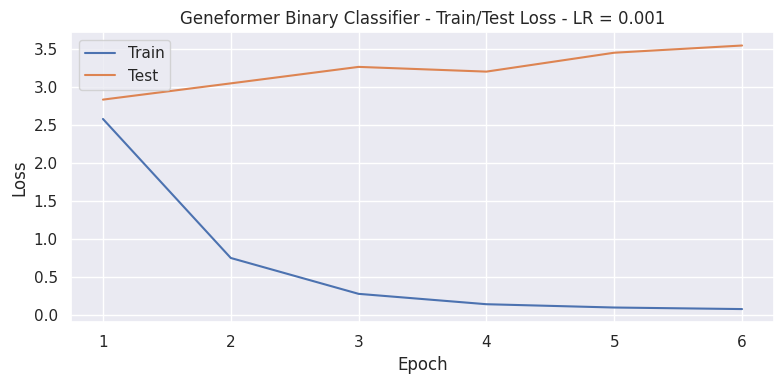

              precision    recall  f1-score   support

        None       0.77      0.71      0.74       404
Relationship       0.73      0.79      0.76       404

    accuracy                           0.75       808
   macro avg       0.75      0.75      0.75       808
weighted avg       0.75      0.75      0.75       808



In [13]:
BINARY_LR = 1e-3
BINARY_EPOCHS = 6

tf_tensor = torch.from_numpy(binary_data.tf_embeddings).float()
tgt_tensor = torch.from_numpy(binary_data.target_embeddings).float()
label_tensor = torch.from_numpy(binary_data.labels).long()

n_classes = len(BINARY_LABELS)

train_idx, test_idx = train_test_split(
    np.arange(len(label_tensor)), test_size=0.1, stratify=binary_data.labels, random_state=42
)

train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

train_losses = []
test_losses = []
for epoch in range(BINARY_EPOCHS):
    classifier.train()
    epoch_loss = 0.0
    for tf_b, tgt_b, lbl_b in train_loader:
        tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
        logits = classifier(tf_b, tgt_b)
        loss = criterion(logits, lbl_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(lbl_b)
    train_losses.append(epoch_loss / len(train_idx))

    classifier.eval()
    test_loss = 0.0
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            test_loss += criterion(logits, lbl_b).item() * len(lbl_b)
    test_losses.append(test_loss / len(test_idx))

epochs = range(1, BINARY_EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Geneformer Binary Classifier - Train/Test Loss - LR = {BINARY_LR}")
plt.legend()
plt.tight_layout()
plt.show()

classifier.eval()
all_preds = []
with torch.no_grad():
    for tf_b, tgt_b, lbl_b in test_loader:
        logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
all_preds = torch.cat(all_preds).numpy()

target_names = [BINARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(binary_data.labels[test_idx], all_preds, target_names=target_names))

### Stratified 5-Fold Cross-Validation

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = np.zeros(len(label_tensor), dtype=np.int64)

for fold, (train_idx, test_idx) in enumerate(skf.split(tf_tensor, label_tensor)):
    train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
    test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(BINARY_EPOCHS):
        classifier.train()
        for tf_b, tgt_b, lbl_b in train_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            loss = criterion(logits, lbl_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    classifier.eval()
    fold_preds = []
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
            fold_preds.append(logits.argmax(dim=1).cpu())
    fold_preds = torch.cat(fold_preds).numpy()
    all_preds[test_idx] = fold_preds

    fold_acc = (fold_preds == binary_data.labels[test_idx]).mean()
    print(f"Fold {fold + 1}: accuracy={fold_acc:.3f} (n={len(test_idx)})")

target_names = [BINARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(binary_data.labels, all_preds, target_names=target_names))

Fold 1: accuracy=0.736 (n=1616)
Fold 2: accuracy=0.734 (n=1615)
Fold 3: accuracy=0.746 (n=1615)
Fold 4: accuracy=0.728 (n=1615)
Fold 5: accuracy=0.758 (n=1615)
              precision    recall  f1-score   support

        None       0.75      0.73      0.74      4038
Relationship       0.74      0.75      0.74      4038

    accuracy                           0.74      8076
   macro avg       0.74      0.74      0.74      8076
weighted avg       0.74      0.74      0.74      8076



## Train Ternary TRRUST Classifier

In [15]:
from scfm_utils.trrust import TERNARY_LABEL_NAMES, TERNARY_LABELS, load_ternary_trrust_data


# Restrict to scGPT ternary gene list for cross-model comparability
scgpt_ternary_genes = set(Path("../data/scgpt_ternary_genes.txt").read_text().split())
ternary_gene_embeddings = {g: v for g, v in gene_embeddings.items() if g in scgpt_ternary_genes}
print(f"Ternary gene embeddings (restricted to scGPT): {len(ternary_gene_embeddings)} genes")

ternary_data = load_ternary_trrust_data(TRRUST_PATH, ternary_gene_embeddings)
print(f"Ternary samples: {len(ternary_data.records)}")
for label_id, name in TERNARY_LABEL_NAMES.items():
    print(f"  {name}: {(ternary_data.labels == label_id).sum()}")

Ternary gene embeddings (restricted to scGPT): 1556 genes
Ternary samples: 3135
  Activation: 1260
  Repression: 830
  None: 1045


### 90/10 Stratified Train-Test Split

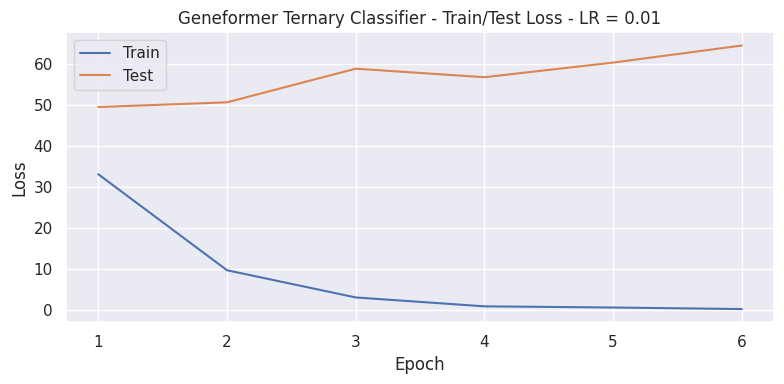

              precision    recall  f1-score   support

  Activation       0.52      0.56      0.54       126
  Repression       0.42      0.39      0.40        83
        None       0.58      0.56      0.57       105

    accuracy                           0.52       314
   macro avg       0.51      0.50      0.50       314
weighted avg       0.51      0.52      0.51       314



In [25]:

TERNARY_LR = 1e-2
TERNARY_EPOCHS = 6

tf_tensor_t = torch.from_numpy(ternary_data.tf_embeddings).float()
tgt_tensor_t = torch.from_numpy(ternary_data.target_embeddings).float()
label_tensor_t = torch.from_numpy(ternary_data.labels).long()

n_classes_t = len(TERNARY_LABELS)

train_idx, test_idx = train_test_split(
    np.arange(len(label_tensor_t)), test_size=0.1, stratify=ternary_data.labels, random_state=42
)

train_ds = TensorDataset(tf_tensor_t[train_idx], tgt_tensor_t[train_idx], label_tensor_t[train_idx])
test_ds = TensorDataset(tf_tensor_t[test_idx], tgt_tensor_t[test_idx], label_tensor_t[test_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

classifier_t = TRRClassifierModel(embsize=embsize, n_classes=n_classes_t).to(DEVICE)
optimizer = torch.optim.Adam(classifier_t.parameters(), lr=TERNARY_LR)
criterion = torch.nn.CrossEntropyLoss()

train_losses, test_losses = [], []
for epoch in range(TERNARY_EPOCHS):
    classifier_t.train()
    epoch_loss = 0.0
    for tf_b, tgt_b, lbl_b in train_loader:
        tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
        logits = classifier_t(tf_b, tgt_b)
        loss = criterion(logits, lbl_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(lbl_b)
    train_losses.append(epoch_loss / len(train_idx))

    classifier_t.eval()
    test_loss = 0.0
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier_t(tf_b, tgt_b)
            test_loss += criterion(logits, lbl_b).item() * len(lbl_b)
    test_losses.append(test_loss / len(test_idx))

epochs = range(1, TERNARY_EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Geneformer Ternary Classifier - Train/Test Loss - LR = {TERNARY_LR}")
plt.legend()
plt.tight_layout()
plt.show()

classifier_t.eval()
all_preds = []
with torch.no_grad():
    for tf_b, tgt_b, lbl_b in test_loader:
        logits = classifier_t(tf_b.to(DEVICE), tgt_b.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
all_preds = torch.cat(all_preds).numpy()

target_names = [TERNARY_LABEL_NAMES[i] for i in range(n_classes_t)]
print(classification_report(ternary_data.labels[test_idx], all_preds, target_names=target_names))

### Stratified 5-Fold Cross-Validation

In [26]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = np.zeros(len(label_tensor_t), dtype=np.int64)

for fold, (train_idx, test_idx) in enumerate(skf.split(tf_tensor_t, label_tensor_t)):
    train_ds = TensorDataset(tf_tensor_t[train_idx], tgt_tensor_t[train_idx], label_tensor_t[train_idx])
    test_ds = TensorDataset(tf_tensor_t[test_idx], tgt_tensor_t[test_idx], label_tensor_t[test_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    classifier_t = TRRClassifierModel(embsize=embsize, n_classes=n_classes_t).to(DEVICE)
    optimizer = torch.optim.Adam(classifier_t.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(TERNARY_EPOCHS):
        classifier_t.train()
        for tf_b, tgt_b, lbl_b in train_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier_t(tf_b, tgt_b)
            loss = criterion(logits, lbl_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    classifier_t.eval()
    fold_preds = []
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            logits = classifier_t(tf_b.to(DEVICE), tgt_b.to(DEVICE))
            fold_preds.append(logits.argmax(dim=1).cpu())
    fold_preds = torch.cat(fold_preds).numpy()
    all_preds[test_idx] = fold_preds

    fold_acc = (fold_preds == ternary_data.labels[test_idx]).mean()
    print(f"Fold {fold + 1}: accuracy={fold_acc:.3f} (n={len(test_idx)})")

target_names = [TERNARY_LABEL_NAMES[i] for i in range(n_classes_t)]
print(classification_report(ternary_data.labels, all_preds, target_names=target_names))

Fold 1: accuracy=0.539 (n=627)
Fold 2: accuracy=0.510 (n=627)
Fold 3: accuracy=0.568 (n=627)
Fold 4: accuracy=0.533 (n=627)
Fold 5: accuracy=0.528 (n=627)
              precision    recall  f1-score   support

  Activation       0.55      0.62      0.58      1260
  Repression       0.43      0.37      0.40       830
        None       0.59      0.57      0.58      1045

    accuracy                           0.54      3135
   macro avg       0.52      0.52      0.52      3135
weighted avg       0.53      0.54      0.53      3135

